In [4]:
!pip install transformers torch scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import numpy as np
import torch
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from torch.utils.data import Dataset

In [6]:
import os

print("Current location:", os.getcwd())

Current location: C:\Users\nukal\Downloads\AI_Email_Deliverability_Intelligence\content\drive\MyDrive\AI_Email_Deliverability_Intelligence\notebooks


In [7]:
os.listdir("../data")

['external', 'processed', 'raw']

In [8]:
import os

for root, dirs, files in os.walk("../data"):
    for file in files:
        print(os.path.join(root, file))

../data\processed\column_inventory.csv
../data\processed\schema_report.csv
../data\processed\sendguard_base_clean.parquet
../data\processed\sendguard_base_processed.parquet
../data\raw\SendGuard900K.csv


In [9]:
import pandas as pd

df = pd.read_parquet("../data/processed/sendguard_base_processed.parquet")

print(df.shape)
df.head()

(908226, 134)


,client_id,client_tag_name,client_tag_num,campaign_id,campaign_test_id,campaign_test_part,campaign_test_type,campaign_sent_time,message_content_size,message_images_count,...,open_rate,click_rate,sent_date,sent_hour,sent_day_of_week,sent_day_name,sent_month,sent_year,has_valid_audience,zero_audience_with_activity
0,171728,None,0,5995662,90351,part,sender_name,2024-04-01 02:00:07+00:00,40968,10,...,23.420074,3.345725,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
1,147025,None,0,5994558,0,0,0,2024-04-01 02:00:08+00:00,11330,5,...,21.201092,6.187443,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
2,171728,None,0,5995663,90351,part,sender_name,2024-04-01 02:00:08+00:00,40968,10,...,23.420074,2.973978,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
3,463419,None,0,5995628,0,0,0,2024-04-01 02:00:40+00:00,81182,21,...,18.529155,1.319349,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
4,503371,None,0,5995646,0,0,0,2024-04-01 03:00:06+00:00,52177,4,...,34.951456,0.970874,2024-04-01,3.0,0.0,Monday,4.0,2024.0,True,False


In [10]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. client_id
2. client_tag_name
3. client_tag_num
4. campaign_id
5. campaign_test_id
6. campaign_test_part
7. campaign_test_type
8. campaign_sent_time
9. message_content_size
10. message_images_count
11. message_embedded_images_count
12. message_embedded_images_size
13. message_embedded_files_count
14. message_embedded_files_size
15. message_links_count
16. message_links_blocked_count
17. message_personalization_tags_count
18. message_personalization_tags_in_sender_email_count
19. message_personalization_tags_in_subject_count
20. message_personalization_tags_in_html_body_count
21. message_personalization_tags_in_text_body_count
22. custom_fields_used_in_campaign
23. campaign_subscribers_count
24. campaign_phantom_bounce_count
25. campaign_subscribers_blocked_count
26. campaign_opens_count
27. campaign_unique_opens_count
28. campaign_clicks_count
29. campaign_unique_clicks_count
30. campaign_soft_bounced_count
31. campaign_hard_bounced_count
32. campaign_resigned_count
33. campaign_comp

In [11]:
keywords = [
    "deliver", "bounce", "spam", "phish",
    "complaint", "open", "click", "label",
    "target", "class", "status"
]

for col in df.columns:
    if any(k in col.lower() for k in keywords):
        print(col)

campaign_phantom_bounce_count
campaign_opens_count
campaign_unique_opens_count
campaign_clicks_count
campaign_unique_clicks_count
campaign_soft_bounced_count
campaign_hard_bounced_count
campaign_complaint_count
campaign_phishing_count
campaign_opens_count_0
campaign_unique_opens_count_0
campaign_clicks_count_0
campaign_unique_clicks_count_0
campaign_soft_bounced_count_0
campaign_hard_bounced_count_0
campaign_complaint_count_0
campaign_opens_count_30
campaign_unique_opens_count_30
campaign_clicks_count_30
campaign_unique_clicks_count_30
campaign_soft_bounced_count_30
campaign_hard_bounced_count_30
campaign_complaint_count_30
campaign_opens_count_60
campaign_unique_opens_count_60
campaign_clicks_count_60
campaign_unique_clicks_count_60
campaign_soft_bounced_count_60
campaign_hard_bounced_count_60
campaign_complaint_count_60
campaign_opens_count_180
campaign_unique_opens_count_180
campaign_clicks_count_180
campaign_unique_clicks_count_180
campaign_soft_bounced_count_180
campaign_hard_boun

In [12]:
def create_status(rate):
    if rate >= 98:
        return "Excellent"
    elif rate >= 95:
        return "Good"
    elif rate >= 90:
        return "Warning"
    else:
        return "Critical"

df["deliverability_status"] = df["delivery_rate"].apply(create_status)

In [13]:
df[["delivery_rate", "deliverability_status"]].head(10)

,delivery_rate,deliverability_status
0,100.000000,Excellent
1,99.818016,Excellent
2,99.628253,Excellent
3,99.929246,Excellent
4,100.000000,Excellent
5,99.909782,Excellent
6,99.871513,Excellent
7,99.938396,Excellent
8,99.953310,Excellent
9,99.518362,Excellent


In [14]:
df["deliverability_status"].value_counts()

deliverability_status
Excellent    736571
Critical      68193
Good          67190
Warning       36272
Name: count, dtype: int64

In [15]:
drop_columns = [
    "deliverability_status",
    "delivery_rate",      # Used to create the target (avoid data leakage)
    "client_id",
    "campaign_id"
]

X = df.drop(columns=drop_columns)
y = df["deliverability_status"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (908226, 131)
Target: (908226,)


In [16]:
X.head()

,client_tag_name,client_tag_num,campaign_test_id,campaign_test_part,campaign_test_type,campaign_sent_time,message_content_size,message_images_count,message_embedded_images_count,message_embedded_images_size,...,open_rate,click_rate,sent_date,sent_hour,sent_day_of_week,sent_day_name,sent_month,sent_year,has_valid_audience,zero_audience_with_activity
0,None,0,90351,part,sender_name,2024-04-01 02:00:07+00:00,40968,10,0,0,...,23.420074,3.345725,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
1,None,0,0,0,0,2024-04-01 02:00:08+00:00,11330,5,0,0,...,21.201092,6.187443,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
2,None,0,90351,part,sender_name,2024-04-01 02:00:08+00:00,40968,10,0,0,...,23.420074,2.973978,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
3,None,0,0,0,0,2024-04-01 02:00:40+00:00,81182,21,0,0,...,18.529155,1.319349,2024-04-01,2.0,0.0,Monday,4.0,2024.0,True,False
4,None,0,0,0,0,2024-04-01 03:00:06+00:00,52177,4,0,0,...,34.951456,0.970874,2024-04-01,3.0,0.0,Monday,4.0,2024.0,True,False


In [17]:
# Target
y = df["deliverability_status"].copy()

# Features
X = df.loc[:, ~df.columns.isin([
    "deliverability_status",
    "delivery_rate",
    "client_id",
    "campaign_id"
])].copy()

print("Feature Matrix:", X.shape)
print("Target Vector :", y.shape)

Feature Matrix: (908226, 131)
Target Vector : (908226,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (726580, 131)
Testing Features  : (181646, 131)
Training Target   : (726580,)
Testing Target    : (181646,)


In [19]:
print("Train Distribution (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest Distribution (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train Distribution (%)
deliverability_status
Excellent    81.10
Critical      7.51
Good          7.40
Warning       3.99
Name: proportion, dtype: float64

Test Distribution (%)
deliverability_status
Excellent    81.10
Critical      7.51
Good          7.40
Warning       3.99
Name: proportion, dtype: float64


In [20]:
# Data type summary
X_train.dtypes.value_counts()

int64                  109
float64                 10
object                   9
bool                     2
datetime64[ns, UTC]      1
Name: count, dtype: int64

In [21]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Features:", len(categorical_cols))
categorical_cols

Categorical Features: 9


['client_tag_name',
 'campaign_test_part',
 'campaign_test_type',
 'domain_in_links_min_creation_time',
 'domain_in_links_max_creation_time',
 'domain_in_links_avg_creation_time',
 'domain_in_links_most_used_creation_time',
 'sent_date',
 'sent_day_name']

In [22]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical Features:", len(numerical_cols))

Numerical Features: 119


In [23]:
datetime_cols = X_train.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Datetime Features:", len(datetime_cols))
datetime_cols

Datetime Features: 0


[]

In [24]:
datetime_cols = X_train.select_dtypes(
    include=["datetimetz"]
).columns.tolist()

print("Datetime Features:", len(datetime_cols))
datetime_cols

Datetime Features: 1


['campaign_sent_time']

In [25]:
for data in [X_train, X_test]:
    data["campaign_hour"] = data["campaign_sent_time"].dt.hour
    data["campaign_day"] = data["campaign_sent_time"].dt.day
    data["campaign_month"] = data["campaign_sent_time"].dt.month

    # Remove original timestamp
    data.drop(columns=["campaign_sent_time"], inplace=True)

In [26]:
print("campaign_sent_time" in X_train.columns)

X_train[["campaign_hour", "campaign_day", "campaign_month"]].head()

False


,campaign_hour,campaign_day,campaign_month
838062,13.0,22.0,1.0
416663,7.0,18.0,9.0
502757,5.0,10.0,10.0
206748,9.0,1.0,11.0
882389,9.0,6.0,3.0


In [27]:
# Remove newly created duplicate features
X_train.drop(
    columns=["campaign_hour", "campaign_day", "campaign_month"],
    inplace=True
)

X_test.drop(
    columns=["campaign_hour", "campaign_day", "campaign_month"],
    inplace=True
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

X_train Shape: (726580, 130)
X_test Shape : (181646, 130)


In [61]:
# Find remaining string columns
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Object columns:", object_cols)
print("Count:", len(object_cols))

Object columns: ['client_tag_name', 'client_tag_num', 'campaign_test_part', 'campaign_test_type', 'domain_in_links_min_creation_time', 'domain_in_links_max_creation_time', 'domain_in_links_avg_creation_time', 'domain_in_links_most_used_creation_time', 'sent_day_name']
Count: 9


In [62]:
# Automatically detect categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(categorical_cols)

['client_tag_name', 'client_tag_num', 'campaign_test_part', 'campaign_test_type', 'domain_in_links_min_creation_time', 'domain_in_links_max_creation_time', 'domain_in_links_avg_creation_time', 'domain_in_links_most_used_creation_time', 'sent_day_name']


In [67]:
import numpy as np
import pandas as pd
import gc

# Find categorical columns without select_dtypes
categorical_columns = []

for col in X_train.columns:
    if X_train[col].dtype == "object" or pd.api.types.is_string_dtype(X_train[col]):
        categorical_columns.append(col)

# Everything else is numerical
numerical_columns = [c for c in X_train.columns if c not in categorical_columns]

# Convert one column at a time
for col in numerical_columns:
    X_train[col] = pd.to_numeric(X_train[col], downcast="float")
    X_test[col] = pd.to_numeric(X_test[col], downcast="float")

gc.collect()

print("Categorical:", len(categorical_columns))
print("Numerical:", len(numerical_columns))

Categorical: 9
Numerical: 121


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            ),
            categorical_columns
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            numerical_columns
        )
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# IMPORTANT: return NumPy/SciPy instead of pandas
preprocessor.set_output(transform="default")

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [70]:
# Fit preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape :", X_test_processed.shape)
print(type(X_train_processed))

MemoryError: Unable to allocate 2.77 MiB for an array with shape (726580, 1) and data type float32

In [50]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['Critical' 'Excellent' 'Good' 'Warning']


In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_encoded)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(3.3296366902518604), np.int64(1): np.float64(0.3082616044639342), np.int64(2): np.float64(3.3793161184700105), np.int64(3): np.float64(6.259735336687573)}


In [52]:
import joblib

joblib.dump(label_encoder, "../models/label_encoder.pkl")

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [54]:
# ==========================================
# CONVERT DATE COLUMNS TO NUMERIC
# ==========================================

import pandas as pd

# Convert sent_date into datetime
X_train["sent_date"] = pd.to_datetime(X_train["sent_date"], errors="coerce")
X_test["sent_date"] = pd.to_datetime(X_test["sent_date"], errors="coerce")

# Convert datetime → integer timestamp (seconds)
X_train["sent_date"] = (
    X_train["sent_date"].astype("int64") // 10**9
)

X_test["sent_date"] = (
    X_test["sent_date"].astype("int64") // 10**9
)

print(X_train["sent_date"].dtype)
print("Date converted successfully")

int64
Date converted successfully


In [33]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [55]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="mlogloss"
)

model.fit(
    X_train_processed,
    y_train_encoded,
    sample_weight=np.array([class_weight_dict[i] for i in y_train_encoded])
)

print("Model trained successfully!")

ValueError: could not convert string to float: '1997-03-29'

In [35]:
# Predict on test data
y_pred = model.predict(X_test_processed)

print("Prediction completed!")

Prediction completed!


In [36]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

accuracy = accuracy_score(y_test_encoded, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.9989

Classification Report:

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00     13639
   Excellent       1.00      1.00      1.00    147315
        Good       0.99      1.00      0.99     13438
     Warning       0.99      0.99      0.99      7254

    accuracy                           1.00    181646
   macro avg       1.00      1.00      1.00    181646
weighted avg       1.00      1.00      1.00    181646



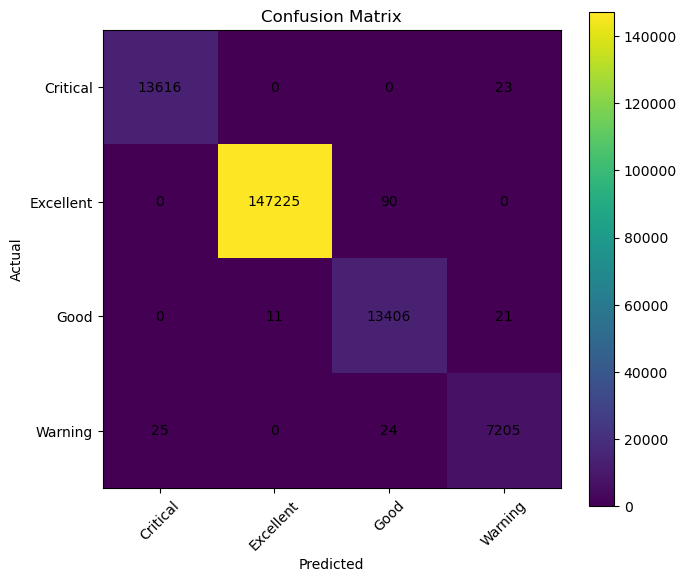

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

classes = label_encoder.classes_

plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [38]:
import joblib

joblib.dump(model, "../models/xgboost_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [39]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

,feature,importance
13169,remainder__has_valid_audience,0.486493
13160,remainder__hard_bounce_rate,0.036972
13066,remainder__campaign_subscribers_count,0.034200
13149,remainder__campaign_soft_bounced_count_4320,0.017534
13159,remainder__soft_bounce_rate,0.017002
13074,remainder__campaign_hard_bounced_count,0.014585
13126,remainder__campaign_hard_bounced_count_720,0.013067
13150,remainder__campaign_hard_bounced_count_4320,0.011686
4336,cat__domain_in_links_avg_creation_time_1997-03-29,0.011661
1,cat__client_tag_name_Dom mediowy,0.010843


In [41]:
import joblib
import pandas as pd

# ===============================
# FIX CATEGORICAL DATATYPES
# ===============================

X_train = X_train.copy()
X_test = X_test.copy()

# These MUST be strings
categorical_cols = ["client_tag_num", "campaign_test_type"]

for col in categorical_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

# Refit preprocessor with corrected dtypes
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Save corrected preprocessor
joblib.dump(preprocessor, "../models/preprocessor_v3.pkl")

print("SUCCESS!")
print("New preprocessor_v3.pkl saved.")
print("X_train shape:", X_train_processed.shape)

SUCCESS!
New preprocessor_v3.pkl saved.
X_train shape: (726580, 13171)


In [46]:
import joblib

# Save the training dataframe dtypes
joblib.dump(X_train.dtypes.to_dict(), "../models/dtype_map_v3.pkl")

print("dtype map saved!")

dtype map saved!


In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Encode target labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Save encoder
joblib.dump(label_encoder, "../models/label_encoder_v3.pkl")

print(label_encoder.classes_)

['Critical' 'Excellent' 'Good' 'Warning']


In [45]:
import joblib
from xgboost import XGBClassifier

# Train V3 model again using the rebuilt preprocessor
model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train_processed, y_train_encoded)

# Save ALL V3 files together
joblib.dump(model, "../models/xgboost_model_v3.pkl")
joblib.dump(preprocessor, "../models/preprocessor_v3.pkl")
joblib.dump(label_encoder, "../models/label_encoder_v3.pkl")

print("SUCCESS!")
print("All V3 files rebuilt.")

SUCCESS!
All V3 files rebuilt.


In [47]:
import joblib

# Save exact feature names and dtypes used for training
schema = {
    "feature_names": list(X_train.columns),
    "dtypes": X_train.dtypes.astype(str).to_dict()
}

joblib.dump(schema, "../models/schema_v3.pkl")

print("schema_v3.pkl created successfully")

schema_v3.pkl created successfully
